In [74]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression

In [75]:
strock=pd.read_csv('healthcare-dataset-stroke-data.csv')

In [76]:
strock.head()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,9046,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,51676,Female,61.0,0,0,Yes,Self-employed,Rural,202.21,NaN,never smoked,1
2,31112,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
3,60182,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
4,1665,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1


In [77]:
strock.tail()

,id,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
5105,18234,Female,80.0,1,0,Yes,Private,Urban,83.75,NaN,never smoked,0
5106,44873,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
5107,19723,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
5108,37544,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0
5109,44679,Female,44.0,0,0,Yes,Govt_job,Urban,85.28,26.2,Unknown,0


In [78]:
strock.columns

Index(['id', 'gender', 'age', 'hypertension', 'heart_disease', 'ever_married',
       'work_type', 'Residence_type', 'avg_glucose_level', 'bmi',
       'smoking_status', 'stroke'],
      dtype='object')

In [79]:
strock.describe()

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,271.740000,97.600000,1.000000


In [80]:
strock.shape

(5110, 12)

In [81]:
strock.dtypes

id                     int64
gender                object
age                  float64
hypertension           int64
heart_disease          int64
ever_married          object
work_type             object
Residence_type        object
avg_glucose_level    float64
bmi                  float64
smoking_status        object
stroke                 int64
dtype: object

In [82]:
strock.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   id                 5110 non-null   int64  
 1   gender             5110 non-null   object 
 2   age                5110 non-null   float64
 3   hypertension       5110 non-null   int64  
 4   heart_disease      5110 non-null   int64  
 5   ever_married       5110 non-null   object 
 6   work_type          5110 non-null   object 
 7   Residence_type     5110 non-null   object 
 8   avg_glucose_level  5110 non-null   float64
 9   bmi                4909 non-null   float64
 10  smoking_status     5110 non-null   object 
 11  stroke             5110 non-null   int64  
dtypes: float64(3), int64(4), object(5)
memory usage: 479.2+ KB


In [83]:
strock=strock[~strock["bmi"].isnull()]

In [84]:
strock["bmi"]

0       36.6
2       32.5
3       34.4
4       24.0
5       29.0
        ... 
5104    18.6
5106    40.0
5107    30.6
5108    25.6
5109    26.2
Name: bmi, Length: 4909, dtype: float64

In [85]:
strock.shape

(4909, 12)

In [86]:
strock.head

<bound method NDFrame.head of          id  gender   age  hypertension  heart_disease ever_married  \
0      9046    Male  67.0             0              1          Yes   
2     31112    Male  80.0             0              1          Yes   
3     60182  Female  49.0             0              0          Yes   
4      1665  Female  79.0             1              0          Yes   
5     56669    Male  81.0             0              0          Yes   
...     ...     ...   ...           ...            ...          ...   
5104  14180  Female  13.0             0              0           No   
5106  44873  Female  81.0             0              0          Yes   
5107  19723  Female  35.0             0              0          Yes   
5108  37544    Male  51.0             0              0          Yes   
5109  44679  Female  44.0             0              0          Yes   

          work_type Residence_type  avg_glucose_level   bmi   smoking_status  \
0           Private          Urban   

In [87]:
strock=strock.reset_index(drop=True)

In [88]:
strock=strock.drop(columns="id")

In [89]:
strock

,gender,age,hypertension,heart_disease,ever_married,work_type,Residence_type,avg_glucose_level,bmi,smoking_status,stroke
0,Male,67.0,0,1,Yes,Private,Urban,228.69,36.6,formerly smoked,1
1,Male,80.0,0,1,Yes,Private,Rural,105.92,32.5,never smoked,1
2,Female,49.0,0,0,Yes,Private,Urban,171.23,34.4,smokes,1
3,Female,79.0,1,0,Yes,Self-employed,Rural,174.12,24.0,never smoked,1
4,Male,81.0,0,0,Yes,Private,Urban,186.21,29.0,formerly smoked,1
...,...,...,...,...,...,...,...,...,...,...,...
4904,Female,13.0,0,0,No,children,Rural,103.08,18.6,Unknown,0
4905,Female,81.0,0,0,Yes,Self-employed,Urban,125.20,40.0,never smoked,0
4906,Female,35.0,0,0,Yes,Self-employed,Rural,82.99,30.6,never smoked,0
4907,Male,51.0,0,0,Yes,Private,Rural,166.29,25.6,formerly smoked,0


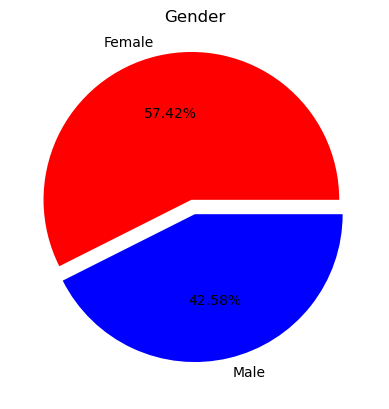

In [90]:
gender = strock.groupby(strock['gender'])['stroke'].sum()
colors = ['red', 'blue']
new_values = gender.values[gender.values != 0]
new_index = gender.index[gender.index != "Other"]
plt.pie(new_values,labels=new_index,colors=colors,explode=(0.1,0),autopct="%1.2f%%")
plt.title("Gender")
plt.show()

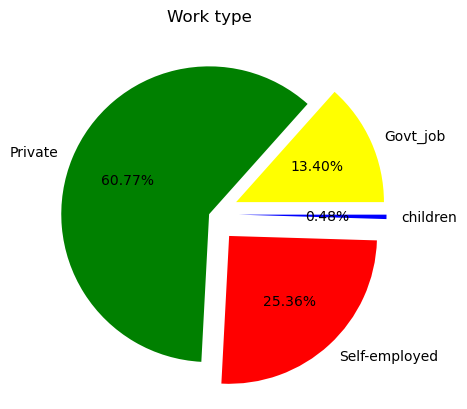

In [91]:
job = strock.groupby(strock['work_type'])['stroke'].sum()
colors2= ['yellow','green','red','blue']
new_values = job.values[job.values != 0]
new_index = job.index[job.index != "Never_worked"]
plt.pie(new_values,labels=new_index,colors=colors2,explode=(0.2,0,0.2,0.2),autopct="%1.2f%%")
plt.title("Work type")
plt.show()

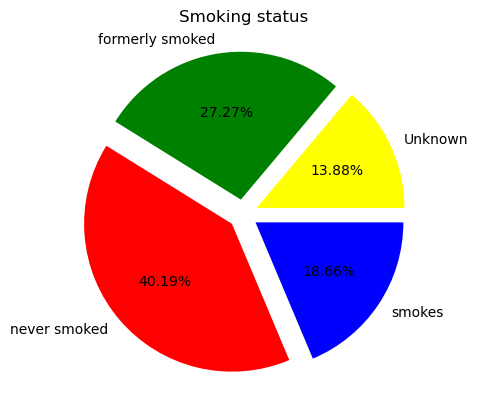

In [92]:
smoke = strock.groupby(strock['smoking_status'])['stroke'].sum()
plt.pie(smoke.values,labels=smoke.index,colors=colors2,explode=(0.1,0.1,0.1,0.1),autopct="%1.2f%%")
plt.title("Smoking status")
plt.show()

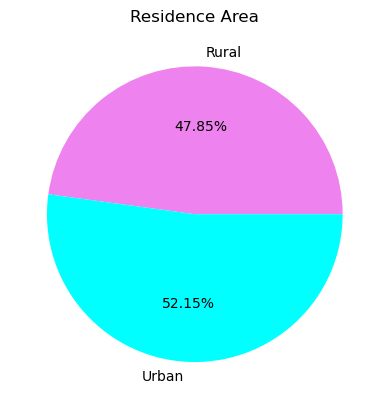

In [93]:
residence = strock.groupby(strock['Residence_type'])['stroke'].sum()
plt.pie(residence.values,labels=residence.index,colors=("violet","aqua"),autopct="%1.2f%%")
plt.title("Residence Area")
plt.show()

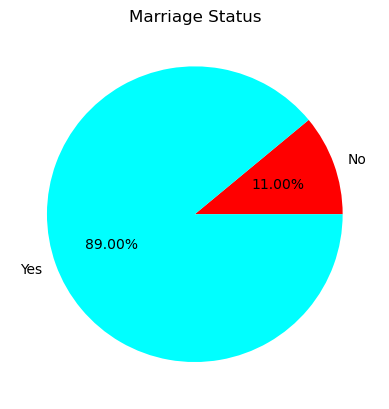

In [94]:
married = strock.groupby(strock['ever_married'])['stroke'].sum()
plt.pie(married.values,labels=married.index,colors=("red","cyan"),autopct="%1.2f%%")
plt.title("Marriage Status")
plt.show()

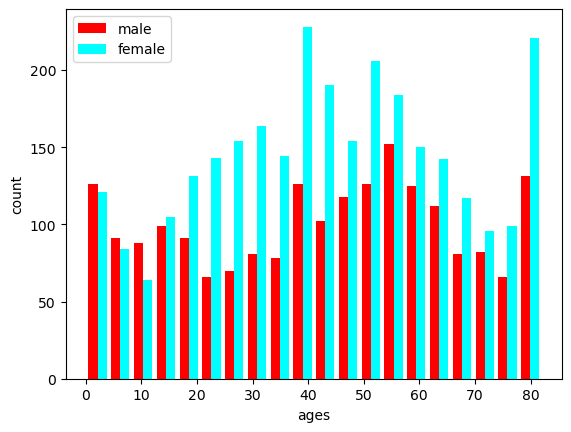

In [95]:
strock[strock['stroke']== 1]
strock["male_age"]=strock[strock["gender"]=="Male"]["age"]
strock["female_age"]=strock[strock["gender"]=="Female"]["age"]
plt.hist(strock[["male_age","female_age"]],bins=20,color=("red","cyan"),label=['male', 'female'])
plt.xlabel("ages")
plt.ylabel("count")
plt.legend()
plt.show()

In [107]:
strock.corr()

,gender,age,hypertension,heart_disease,ever_married,avg_glucose_level,bmi,stroke,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
gender,1.000000,0.030457,-0.021730,-0.082882,0.036703,-0.053358,0.026360,-0.006851,0.015123,-0.012297,0.038611,0.022312,-0.091619,-0.004598,0.004598,-0.057893,-0.039592,0.094051,-0.011519
age,0.030457,1.000000,0.274425,0.257123,0.680782,0.235838,0.333398,0.232331,0.133593,-0.079384,0.120021,0.327347,-0.634937,-0.010948,0.010948,-0.389577,0.242404,0.124377,0.076801
hypertension,-0.021730,0.274425,1.000000,0.115991,0.162406,0.180543,0.167811,0.142515,0.019232,-0.021341,-0.004637,0.111794,-0.126561,0.001074,-0.001074,-0.143219,0.062078,0.066717,0.028214
heart_disease,-0.082882,0.257123,0.115991,1.000000,0.111245,0.154525,0.041357,0.137938,0.005095,-0.015312,-0.000279,0.081484,-0.088072,0.002362,-0.002362,-0.074468,0.071339,-0.020685,0.048686
ever_married,0.036703,0.680782,0.162406,0.111245,1.000000,0.151377,0.341695,0.105089,0.137915,-0.091976,0.156818,0.191469,-0.545462,-0.004989,0.004989,-0.338169,0.176007,0.105253,0.106574
avg_glucose_level,-0.053358,0.235838,0.180543,0.154525,0.151377,1.000000,0.175502,0.138936,0.017723,-0.013991,0.009273,0.069051,-0.101182,0.007617,-0.007617,-0.103225,0.074250,0.032085,0.010981
bmi,0.026360,0.333398,0.167811,0.041357,0.341695,0.175502,1.000000,0.042374,0.079584,-0.028602,0.208029,0.072701,-0.448674,0.000122,-0.000122,-0.270340,0.107031,0.107964,0.088324
stroke,-0.006851,0.232331,0.142515,0.137938,0.105089,0.138936,0.042374,1.000000,0.003553,-0.014149,0.014934,0.055356,-0.080971,-0.006031,0.006031,-0.075016,0.057320,0.010723,0.021530
work_type_Govt_job,0.015123,0.133593,0.019232,0.005095,0.137915,0.017723,0.079584,0.003553,1.000000,-0.025745,-0.444147,-0.166136,-0.152679,-0.010287,0.010287,-0.098583,0.030095,0.046898,0.031402
work_type_Never_worked,-0.012297,-0.079384,-0.021341,-0.015312,-0.091976,-0.013991,-0.028602,-0.014149,-0.025745,1.000000,-0.077664,-0.029051,-0.026698,-0.023430,0.023430,0.008992,-0.030419,0.035866,-0.028200


<Axes: >

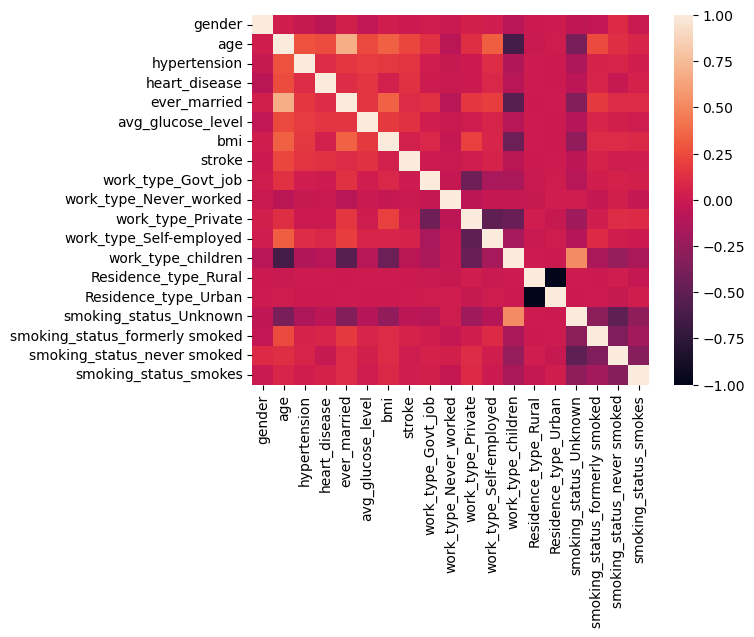

In [108]:
sns.heatmap(strock.corr())

In [96]:
strock=strock.drop(columns="male_age")
strock=strock.drop(columns="female_age")

In [97]:
strock['ever_married'] = [ 0 if i !='Yes' else 1 for i in strock['ever_married'] ]
strock['gender'] = [0 if i != 'Female' else 1 for i in strock['gender']]
strock = pd.get_dummies(strock, columns = ['work_type', 'Residence_type','smoking_status'])
boolean_columns = strock.select_dtypes(include=['bool']).columns
strock[boolean_columns] = strock[boolean_columns].astype(int)
strock.sample(5)

,gender,age,hypertension,heart_disease,ever_married,avg_glucose_level,bmi,stroke,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
1084,1,7.0,0,0,0,88.60,17.4,0,0,0,0,0,1,0,1,1,0,0,0
4281,1,12.0,0,0,0,70.13,17.8,0,0,0,0,0,1,1,0,1,0,0,0
3970,0,66.0,0,1,0,70.28,34.5,0,1,0,0,0,0,0,1,0,0,1,0
4850,1,51.0,0,0,1,95.16,42.7,0,1,0,0,0,0,0,1,0,1,0,0
4046,1,37.0,0,0,1,77.10,55.9,0,0,0,1,0,0,1,0,1,0,0,0


In [98]:
X=strock.drop("stroke",axis=1)
y=strock["stroke"]

In [99]:
X

,gender,age,hypertension,heart_disease,ever_married,avg_glucose_level,bmi,work_type_Govt_job,work_type_Never_worked,work_type_Private,work_type_Self-employed,work_type_children,Residence_type_Rural,Residence_type_Urban,smoking_status_Unknown,smoking_status_formerly smoked,smoking_status_never smoked,smoking_status_smokes
0,0,67.0,0,1,1,228.69,36.6,0,0,1,0,0,0,1,0,1,0,0
1,0,80.0,0,1,1,105.92,32.5,0,0,1,0,0,1,0,0,0,1,0
2,1,49.0,0,0,1,171.23,34.4,0,0,1,0,0,0,1,0,0,0,1
3,1,79.0,1,0,1,174.12,24.0,0,0,0,1,0,1,0,0,0,1,0
4,0,81.0,0,0,1,186.21,29.0,0,0,1,0,0,0,1,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4904,1,13.0,0,0,0,103.08,18.6,0,0,0,0,1,1,0,1,0,0,0
4905,1,81.0,0,0,1,125.20,40.0,0,0,0,1,0,0,1,0,0,1,0
4906,1,35.0,0,0,1,82.99,30.6,0,0,0,1,0,1,0,0,0,1,0
4907,0,51.0,0,0,1,166.29,25.6,0,0,1,0,0,1,0,0,1,0,0


In [100]:
y

0       1
1       1
2       1
3       1
4       1
       ..
4904    0
4905    0
4906    0
4907    0
4908    0
Name: stroke, Length: 4909, dtype: int64

In [101]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.1)

In [102]:
print(X.shape,X_train.shape,X_test.shape)

(4909, 18) (4418, 18) (491, 18)


In [103]:
print(y.shape,y_train.shape,y_test.shape)

(4909,) (4418,) (491,)


In [104]:
model=LogisticRegression()
model.fit(X_train,y_train)

c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [105]:
prediction=model.predict(X_test)
print(prediction)

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0]


In [106]:
accuracy=accuracy_score(prediction,y_test)
accuracy

0.9653767820773931